# 03 - Table 5: Ablation Study (ĐA LỚP / Multiclass)

Đánh giá vai trò từng thành phần trên bài toán đa lớp: Full / NoFeatureSelect (dùng toàn bộ one-hot) /
NoBatchNorm / NoDropout / NoScheduler. Tất cả dùng softmax + sparse_categorical_crossentropy.

In [1]:
# === Thiết lập môi trường ỔN ĐỊNH (tránh lỗi Drive 'Transport endpoint is not connected') ===
# Làm việc trên Ổ CỨNG LOCAL /content (nhanh + ổn định); chỉ ĐỒNG BỘ kết quả về Drive ở cuối.
import os, time, shutil
from contextlib import contextmanager

DRIVE = '/content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final'
PROJECT_PATH = '/content/cdmlp'
NEED_RAW = False   # True chi voi notebook 08 (cross-dataset can data/raw)
ON_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    ON_COLAB = True
except Exception:
    here = os.getcwd()
    while here != os.path.dirname(here) and not os.path.isdir(os.path.join(here, 'notebooks')):
        here = os.path.dirname(here)
    DRIVE = here; PROJECT_PATH = here

def _pull(rel):
    s = os.path.join(DRIVE, rel); d = os.path.join(PROJECT_PATH, rel)
    if os.path.isdir(s): shutil.copytree(s, d, dirs_exist_ok=True)
    elif os.path.isfile(s):
        os.makedirs(os.path.dirname(d), exist_ok=True); shutil.copy2(s, d)

if ON_COLAB:
    os.makedirs(PROJECT_PATH, exist_ok=True)
    for rel in ['scripts','src','models','results','data/colab_processed','data/ton_iot.csv']:
        try: _pull(rel)
        except Exception as e: print('  (bo qua)', rel, e)
    if NEED_RAW:
        print('  Dang keo data/raw (~550MB, 1-3 phut)...')
        try: _pull('data/raw')
        except Exception as e: print('  (bo qua) data/raw', e)

os.makedirs(PROJECT_PATH, exist_ok=True); os.chdir(PROJECT_PATH)
try:
    get_ipython().run_line_magic('cd', PROJECT_PATH)  # dam bao '!python ...' cung chay o local dir
except Exception:
    pass
for d in ('data/colab_processed','results','results/xai','models'):
    os.makedirs(d, exist_ok=True)
print('PROJECT_PATH (local) =', PROJECT_PATH, '| ON_COLAB =', ON_COLAB)

def find_data_csv():
    for c in ['data/ton_iot.csv','data/raw/ton_iot.csv','ton_iot.csv']:
        if os.path.exists(c): return c
    raise FileNotFoundError('Khong tim thay ton_iot.csv (Drive: data/ton_iot.csv).')

@contextmanager
def step(name):
    t0=time.time(); print(f'\n[START] {name}', flush=True)
    try: yield
    finally: print(f'[DONE] {name} - {time.time()-t0:.1f}s', flush=True)

def sync_to_drive():
    if not ON_COLAB:
        print('[local] bo qua sync Drive'); return
    for rel in ['data/colab_processed','models','results']:
        s = os.path.join(PROJECT_PATH, rel)
        if os.path.exists(s): shutil.copytree(s, os.path.join(DRIVE, rel), dirs_exist_ok=True)
    print('[OK] Da dong bo ket qua ve Drive:', DRIVE)


Mounted at /content/drive
/content
PROJECT_PATH (local) = /content/cdmlp | ON_COLAB = True


In [2]:
!pip -q install pandas numpy tensorflow scikit-learn pyarrow matplotlib


[START] Load artifacts
[DONE] Load artifacts - 0.3s
[INFO] top30 (168834, 30) | all (168834, 124) | classes 10

[START] Ablation: Full Model
Epoch 1/100
2111/2111 - 34s - 16ms/step - accuracy: 0.7494 - loss: 0.7295 - val_accuracy: 0.7931 - val_loss: 0.5260 - learning_rate: 0.0010
Epoch 2/100
2111/2111 - 6s - 3ms/step - accuracy: 0.7893 - loss: 0.6007 - val_accuracy: 0.8023 - val_loss: 0.5388 - learning_rate: 9.9976e-04
Epoch 3/100
2111/2111 - 5s - 3ms/step - accuracy: 0.8045 - loss: 0.5593 - val_accuracy: 0.8221 - val_loss: 0.4312 - learning_rate: 9.9902e-04
Epoch 4/100
2111/2111 - 5s - 3ms/step - accuracy: 0.8179 - loss: 0.5296 - val_accuracy: 0.8277 - val_loss: 0.4229 - learning_rate: 9.9780e-04
Epoch 5/100
2111/2111 - 5s - 3ms/step - accuracy: 0.8277 - loss: 0.5108 - val_accuracy: 0.8456 - val_loss: 0.3887 - learning_rate: 9.9610e-04
Epoch 6/100
2111/2111 - 6s - 3ms/step - accuracy: 0.8304 - loss: 0.5006 - val_accuracy: 0.8503 - val_loss: 0.3952 - learning_rate: 9.9391e-04
Epoch 7/

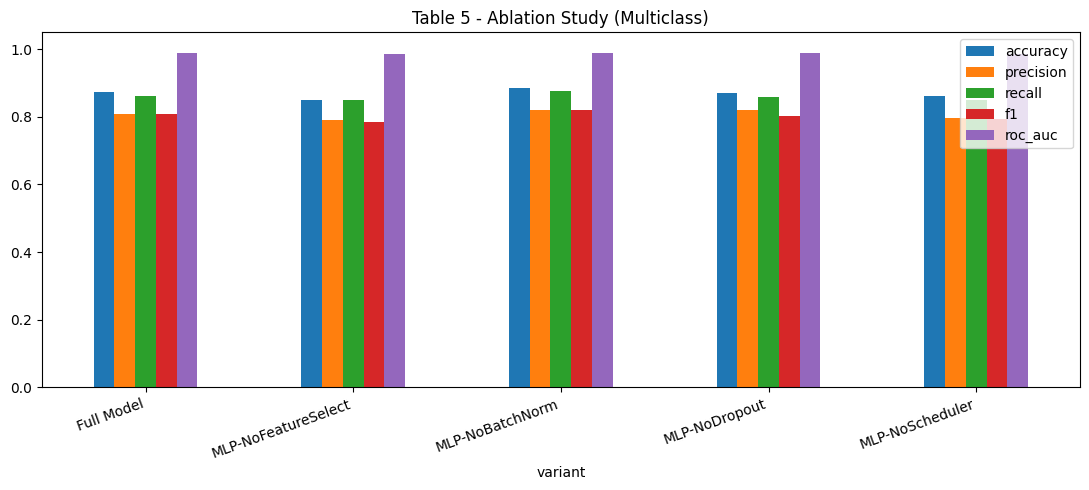

In [3]:
import os, json, time, math, random
import numpy as np, pandas as pd, tensorflow as tf, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import Adam

OUT='data/colab_processed'; RESULTS='results'; MODELS='models'; os.makedirs(RESULTS, exist_ok=True)
meta = json.load(open(f'{MODELS}/colab_preprocessing_metadata.json', encoding='utf-8'))
N_CLASSES = meta['n_classes']
with step('Load artifacts'):
    y_train=pd.read_parquet(f'{OUT}/y_train.parquet')['label'].values.astype(int)
    y_test =pd.read_parquet(f'{OUT}/y_test.parquet')['label'].values.astype(int)
    Xtop_tr=pd.read_parquet(f'{OUT}/X_train_top30.parquet').values.astype('float32')
    Xtop_te=pd.read_parquet(f'{OUT}/X_test_top30.parquet').values.astype('float32')
    Xall_tr=pd.read_parquet(f'{OUT}/X_train_all.parquet').values.astype('float32')
    Xall_te=pd.read_parquet(f'{OUT}/X_test_all.parquet').values.astype('float32')
print('[INFO] top30', Xtop_tr.shape, '| all', Xall_tr.shape, '| classes', N_CLASSES)

def seed(): random.seed(42); np.random.seed(42); tf.random.set_seed(42)
def cosine(e, T=100): return 1e-5 + .5*(1e-3-1e-5)*(1+math.cos(math.pi*e/T))
def build(dim, variant):
    m=Sequential([Input(shape=(dim,))])
    for u in [512,256,128]:
        m.add(Dense(u, activation='relu'))
        if variant!='no_batchnorm': m.add(BatchNormalization())
        if variant!='no_dropout': m.add(Dropout(0.3))
    m.add(Dense(N_CLASSES, activation='softmax'))
    m.compile(Adam(1e-3), 'sparse_categorical_crossentropy', metrics=['accuracy']); return m

def run(name, variant, Xtr, Xte, scheduler=True):
    with step(f'Ablation: {name}'):
        seed(); model=build(Xtr.shape[1], variant)
        cb=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
        if scheduler: cb.append(LearningRateScheduler(lambda e: cosine(e)))
        w=compute_class_weight('balanced', classes=np.unique(y_train), y=y_train); cw=dict(enumerate(w))
        t=time.time(); h=model.fit(Xtr, y_train, validation_split=.2, epochs=100, batch_size=64, callbacks=cb, class_weight=cw, verbose=2)
        prob=model.predict(Xte, verbose=0); yp=prob.argmax(1)
        try: auc=roc_auc_score(y_test, prob, multi_class='ovr', average='macro')
        except Exception: auc=float('nan')
        return {'variant':name, 'accuracy':accuracy_score(y_test,yp),
                'precision':precision_score(y_test,yp,average='macro',zero_division=0),
                'recall':recall_score(y_test,yp,average='macro',zero_division=0),
                'f1':f1_score(y_test,yp,average='macro',zero_division=0), 'roc_auc':auc,
                'train_time_sec':time.time()-t, 'epochs_ran':len(h.history['loss'])}

rows=[run('Full Model','full',Xtop_tr,Xtop_te),
      run('MLP-NoFeatureSelect','full',Xall_tr,Xall_te),
      run('MLP-NoBatchNorm','no_batchnorm',Xtop_tr,Xtop_te),
      run('MLP-NoDropout','no_dropout',Xtop_tr,Xtop_te),
      run('MLP-NoScheduler','full',Xtop_tr,Xtop_te,False)]
df=pd.DataFrame(rows); df.to_csv(f'{RESULTS}/colab_ablation_metrics.csv', index=False); print(df.to_string(index=False))
df.set_index('variant')[['accuracy','precision','recall','f1','roc_auc']].plot(kind='bar', figsize=(11,5))
plt.ylim(0,1.05); plt.title('Table 5 - Ablation Study (Multiclass)'); plt.xticks(rotation=20, ha='right'); plt.tight_layout()
plt.savefig(f'{RESULTS}/fig_colab_ablation.png', dpi=150); plt.show()

In [5]:
# === ĐỒNG BỘ KẾT QUẢ VỀ GOOGLE DRIVE (chạy cuối cùng, sau khi các cell trên xong) ===
sync_to_drive()


[OK] Da dong bo ket qua ve Drive: /content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final
